<a href="https://colab.research.google.com/github/lfmuneramm/Aprendizaje_No_Supervisado/blob/main/Proyecto_Final_Anal%C3%ADtica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Descripción Caso de Estudio**

- Luis Felipe Munera
- Sara Arango
- Manuel Jaramillo

El presente caso de estudio se basa en la base de datos “Fatal Encounters”, disponible en la plataforma Kaggle, la cual tiene como propósito construir un registro imparcial, completo y de libre acceso sobre las personas que han perdido la vida durante interacciones con fuerzas policiales en los Estados Unidos. Este proyecto surge ante la ausencia de información oficial y sistemática sobre estos hechos, ya que, hasta hace pocos años, ninguna entidad gubernamental recopilaba ni publicaba datos detallados sobre el uso letal de la fuerza por parte de la policía.

La iniciativa nació en 2012, luego de que un periodista del Reno News & Review se percatara de que las noticias sobre muertes en enfrentamientos policiales carecían de contexto: no existían cifras que indicaran cuántas personas habían muerto en circunstancias similares ni bajo qué condiciones ocurrían estos hechos. A partir de esa inquietud, se comenzó un proceso de recolección, verificación y sistematización de casos a nivel nacional, con el fin de ofrecer una fuente de datos confiable para el análisis público, académico y social.

Este caso de estudio, se busca aprovechar esta base de datos para realizar un análisis exploratorio y de sentimientos, utilizando la información textual de los reportes (principalmente en la columna “Brief description”). A través de diferentes técnicas de procesamiento y visualización, se pretende identificar tendencias emocionales, patrones de conducta y relaciones entre el tipo de fuerza empleada, los sentimientos expresados y otros factores relevantes.

A continuación se describirán las variables que sirvieron de análisis para el caso de estudio:
- Age:	Edad de la persona al momento del fallecimiento. Es una variable numérica útil para el análisis demográfico y la detección de patrones.
- Gender:	Género de la persona. Permite evaluar posibles diferencias por sexo en el uso de la fuerza.
- Race:	Etnia o raza reportada originalmente. Puede contener valores faltantes o categorías amplias.
- Race with imputations: Raza estimada o imputada por el proyecto con base en fuentes adicionales cuando no había datos disponibles.
- Date of injury resulting in death (month/day/year): Fecha en la que ocurrió la lesión que condujo a la muerte.
- Location of death (city): Ciudad donde se registró el fallecimiento. Permite realizar análisis geográficos.
- State:	Estado de los Estados Unidos donde ocurrió el incidente. Útil para comparaciones regionales.
- Latitude y Longitude: Coordenadas geográficas exactas del lugar del incidente. Permiten realizar visualizaciones en mapas y análisis espaciales.
- Highest level of force: Nivel más alto de fuerza utilizado por las autoridades, como “Gunshot”, “Taser”, “Physical restraint”, entre otros.
- Armed/Unarmed: Indica si la persona se encontraba armada o desarmada al momento del incidente. Es una variable importante para evaluar la proporcionalidad del uso de fuerza.
- Alleged weapon:	Tipo de arma presuntamente en posesión de la persona (por ejemplo, firearm, knife, vehicle, none).
- Aggressive physical movement: Indica si la persona realizó movimientos físicos agresivos hacia los oficiales.
- Fleeing/Not fleeing:	Señala si la persona intentó huir durante el enfrentamiento. Puede tener valores como “Fleeing”, “Not fleeing” o “Unknown”.
- Brief description: Descripción breve del incidente, escrita en lenguaje natural. Esta columna se utiliza como fuente principal para el análisis de sentimientos, ya que contiene la narrativa textual del hecho.
- Foreknowledge of mental illness? INTERNAL USE, NOT FOR ANALYSIS: Indica si las autoridades tenían conocimiento previo de una posible enfermedad mental del individuo.


#Preprocesamiento

In [ ]:
# Paso 0: Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones estéticas para gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar el archivo con el separador correcto
ruta = "/content/dataset.csv"
df = pd.read_csv(ruta, sep=";")

# Mostrar tamaño y primeras filas
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 30799, Columnas: 36


/tmp/ipython-input-924920422.py:13: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, sep=";")


,Unique ID,Name,Age,Gender,Race,Race with imputations,Imputation probability,URL of image (PLS NO HOTLINKS),Date of injury resulting in death (month/day/year),Location of injury (address),...,URL Temp,Brief description,"Dispositions/Exclusions INTERNAL USE, NOT FOR ANALYSIS",Intended use of force (Developing),Supporting document link,"Foreknowledge of mental illness? INTERNAL USE, NOT FOR ANALYSIS",Unnamed: 32,Unnamed: 33,Unique ID formula,Unique identifier (redundant)
0,25747.0,Mark A. Horton,21,Male,African-American/Black,African-American/Black,Not imputed,NaN,01/01/2000,Davison Freeway,...,NaN,Two Detroit men killed when their car crashed ...,Unreported,Pursuit,https://drive.google.com/file/d/1-nK-RohgiM-tZ...,No,NaN,NaN,NaN,25747.0
1,25748.0,Phillip A. Blurbridge,19,Male,African-American/Black,African-American/Black,Not imputed,NaN,01/01/2000,Davison Freeway,...,NaN,Two Detroit men killed when their car crashed ...,Unreported,Pursuit,https://drive.google.com/file/d/1-nK-RohgiM-tZ...,No,NaN,NaN,NaN,25748.0
2,25746.0,Samuel H. Knapp,17,Male,European-American/White,European-American/White,Not imputed,NaN,01/01/2000,27898-27804 US-101,...,NaN,Samuel Knapp was allegedly driving a stolen ve...,Unreported,Pursuit,https://drive.google.com/file/d/10DisrV8K5ReP1...,No,NaN,NaN,NaN,25746.0
3,25749.0,Mark Ortiz,23,Male,Hispanic/Latino,Hispanic/Latino,Not imputed,NaN,01/01/2000,600 W Cherry Ln,...,NaN,A motorcycle was allegedly being driven errati...,Unreported,Pursuit,https://drive.google.com/file/d/1qAEefRjX_aTtC...,No,NaN,NaN,NaN,25749.0
4,1.0,LaTanya Janelle McCoy,24,Female,African-American/Black,African-American/Black,Not imputed,NaN,01/02/2000,5700 block Mack Road,...,NaN,LaTanya Janelle McCoy's car was struck from be...,Unknown,Pursuit,http://www.recordnet.com/article/20000110/A_NE...,No,NaN,NaN,NaN,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30799 entries, 0 to 30798
Data columns (total 36 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Unique ID                                                        30798 non-null  float64
 1   Name                                                             30799 non-null  object 
 2   Age                                                              29630 non-null  object 
 3   Gender                                                           30661 non-null  object 
 4   Race                                                             30798 non-null  object 
 5   Race with imputations                                            30111 non-null  object 
 6   Imputation probability                                           30092 non-null  object 
 7   URL of image (PLS NO HOTLINKS)          

In [ ]:
print(df.columns.tolist())


['Unique ID', 'Name', 'Age', 'Gender', 'Race', 'Race with imputations', 'Imputation probability', 'URL of image (PLS NO HOTLINKS)', ' Date of injury resulting in death (month/day/year)', 'Location of injury (address)', 'Location of death (city)', 'State', 'Location of death (zip code)', 'Location of death (county)', 'Full Address', 'Latitude', 'Longitude', 'Agency or agencies involved', 'Highest level of force', 'UID Temporary', 'Name Temporary', 'Armed/Unarmed', 'Alleged weapon', 'Aggressive physical movement', 'Fleeing/Not fleeing', 'Description Temp', 'URL Temp', 'Brief description', 'Dispositions/Exclusions INTERNAL USE, NOT FOR ANALYSIS', 'Intended use of force (Developing)', 'Supporting document link', 'Foreknowledge of mental illness? INTERNAL USE, NOT FOR ANALYSIS', 'Unnamed: 32', 'Unnamed: 33', 'Unique ID formula', 'Unique identifier (redundant)']


In [ ]:
df.describe()

,Unique ID,Location of death (zip code),UID Temporary,Unnamed: 32,Unnamed: 33,Unique ID formula,Unique identifier (redundant)
count,30798.000000,30613.000000,2304.000000,0.0,1.0,2.000000,30798.000000
mean,15399.500000,58425.618626,16837.402344,NaN,10895.0,29147.500000,15399.500000
std,8890.761132,27965.886117,6645.974628,NaN,NaN,2334.159485,8890.761132
min,1.000000,1013.000000,11865.000000,NaN,10895.0,27497.000000,1.000000
25%,7700.250000,33150.000000,12744.750000,NaN,10895.0,28322.250000,7700.250000
50%,15399.500000,60653.000000,13326.500000,NaN,10895.0,29147.500000,15399.500000
75%,23098.750000,85042.000000,19125.250000,NaN,10895.0,29972.750000,23098.750000
max,30798.000000,99921.000000,29572.000000,NaN,10895.0,30798.000000,30798.000000


In [ ]:
df.isnull().sum()

,0
Unique ID,1
Name,0
Age,1169
Gender,138
Race,1
Race with imputations,688
Imputation probability,707
URL of image (PLS NO HOTLINKS),16480
Date of injury resulting in death (month/day/year),0
Location of injury (address),553


In [ ]:
# Renombrar la columna para facilitar el manejo
df.rename(columns={' Date of injury resulting in death (month/day/year)': 'Date_of_death'}, inplace=True)

# Convertir la nueva columna 'date_of_death' a datetime
df['Date_of_death'] = pd.to_datetime(df['Date_of_death'], errors='coerce')

# Mostrar las primeras filas para verificar
print(df['Date_of_death'].head())


0   2000-01-01
1   2000-01-01
2   2000-01-01
3   2000-01-01
4   2000-01-02
Name: Date_of_death, dtype: datetime64[ns]


In [ ]:
# Copiar el DataFrame original
df_limpio = df.copy()

# Renombrar la columna 'Location of death (city/state)' a 'City'
df_limpio.rename(columns={'Location of death (city)': 'City'}, inplace=True)
# Eliminar columnas irrelevantes
columnas_a_eliminar = [
    'Unique ID',
    'Name',
    'URL of image (PLS NO HOTLINKS)',
    'Location of injury (address)',
    'Location of death (zip code)',
    'Location of death (county)',
    'Full Address',
    'Agency or agencies involved',
    'UID Temporary',
    'Name Temporary',
    'Description Temp',
    'URL Temp',
    'Dispositions/Exclusions INTERNAL USE, NOT FOR ANALYSIS',
    'Intended use of force (Developing)'
    'Supporting document link',
    'Unnamed: 32',
    'Unnamed: 33',
    'Unique ID formula',
    'Unique identifier (redundant)',
    'URL of news article',
    'Unique ID'
]

# Eliminar columnas si están en el DataFrame
df_limpio = df_limpio.drop(columns=[col for col in columnas_a_eliminar if col in df_limpio.columns])

# Mostrar las columnas restantes
print("Columnas después de la limpieza:")
print(df_limpio.columns.tolist())

# Verificar valores faltantes
print("\nValores faltantes por columna:")
print(df_limpio.isnull().sum())


Columnas después de la limpieza:
['Age', 'Gender', 'Race', 'Race with imputations', 'Imputation probability', 'Date_of_death', 'City', 'State', 'Latitude', 'Longitude', 'Highest level of force', 'Armed/Unarmed', 'Alleged weapon', 'Aggressive physical movement', 'Fleeing/Not fleeing', 'Brief description', 'Intended use of force (Developing)', 'Supporting document link', 'Foreknowledge of mental illness? INTERNAL USE, NOT FOR ANALYSIS']

Valores faltantes por columna:
Age                                                                 1169
Gender                                                               138
Race                                                                   1
Race with imputations                                                688
Imputation probability                                               707
Date_of_death                                                          0
City                                                                  39
State             

In [ ]:

import pandas as pd

# Cargar el archivo con el separador correcto
ruta = "/content/dataset (1).csv"
# Intenta especificar el encoding si es necesario
try:
    df = pd.read_csv(ruta, sep=";")
except UnicodeDecodeError:
    print("Error de codificación, intentando con 'latin-1'")
    df = pd.read_csv(ruta, sep=";", encoding='latin-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")


# Renombrar la columna de fecha
df.rename(columns={' Date of injury resulting in death (month/day/year)': 'Date_of_death'}, inplace=True)

# Intentar convertir la columna de fecha especificando un formato común
# Ajusta el formato ('%m/%d/%Y') según cómo aparezcan las fechas en tu archivo Excel
try:
    df['Date_of_death'] = pd.to_datetime(df['Date_of_death'], format='%m/%d/%Y', errors='coerce')
except ValueError:
    print("No se pudo convertir con el formato '%m/%d/%Y', intentando sin formato específico.")
    df['Date_of_death'] = pd.to_datetime(df['Date_of_death'], errors='coerce')


# Imprimir el rango de fechas después de la conversión
print("\nRango de fechas después de la conversión:")
print(f"Fecha mínima: {df['Date_of_death'].min()}")
print(f"Fecha máxima: {df['Date_of_death'].max()}")

# Filtrar desde el año 2013 en adelante
df_filtrado = df[df['Date_of_death'].dt.year >= 2013]

print(f"\nNúmero de filas después del filtrado por año 2013+: {df_filtrado.shape[0]}")



Rango de fechas después de la conversión:
Fecha mínima: 2000-01-01 00:00:00
Fecha máxima: 2021-08-19 00:00:00

Número de filas después del filtrado por año 2013+: 15557


/tmp/ipython-input-385793311.py:7: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, sep=";")


In [ ]:
# Asegurarse de que la columna de fecha esté en formato datetime
if 'Date_of_death' in df_limpio.columns:
    df_limpio['Date_of_death'] = pd.to_datetime(df_limpio['Date_of_death'], errors='coerce')

    # Filtrar desde el año 2013 en adelante
    df_filtrado = df_limpio[df_limpio['Date_of_death'].dt.year >= 2013]

    # Mostrar los primeros registros para verificar
    print("Primeros registros después del filtrado:")
    print(df_filtrado.head())

Primeros registros después del filtrado:
      Age  Gender                     Race    Race with imputations  \
15241  29  Female          Hispanic/Latino          Hispanic/Latino   
15242  26    Male          Hispanic/Latino          Hispanic/Latino   
15243  31    Male   African-American/Black   African-American/Black   
15244  21    Male  European-American/White  European-American/White   
15245  26    Male  European-American/White  European-American/White   

      Imputation probability Date_of_death           City State    Latitude  \
15241            Not imputed    2013-01-01  San Francisco    CA  37,7571758   
15242            Not imputed    2013-01-01  San Francisco    CA  37,7571758   
15243            Not imputed    2013-01-01          Omaha    NE  41,2930875   
15244            Not imputed    2013-01-01         Gordon    WI  46,2508616   
15245            Not imputed    2013-01-01        Mankato    MN  44,1659029   

          Longitude Highest level of force Armed/Unarmed 

In [ ]:
# Asegurarse de que la columna de fecha esté en formato datetime y manejar errores
if 'Date_of_death' in df_limpio.columns:
    # Convertir a datetime, los valores que no se pueden convertir serán NaT
    df_limpio['Date_of_death'] = pd.to_datetime(df_limpio['Date_of_death'], errors='coerce')

    # Filtrar desde el año 2013 en adelante
    df_filtrado = df_limpio[df_limpio['Date_of_death'].dt.year >= 2013]

    print(f"\nNúmero de filas después del filtrado por año 2013+: {df_filtrado.shape[0]}")

    # Mostrar los primeros registros para verificar
    print("\nPrimeros registros después del filtrado:")
    display(df_filtrado.head())
else:
    print("La columna 'Date_of_death' no está en el DataFrame.")


Número de filas después del filtrado por año 2013+: 15558

Primeros registros después del filtrado:


,Age,Gender,Race,Race with imputations,Imputation probability,Date_of_death,City,State,Latitude,Longitude,Highest level of force,Armed/Unarmed,Alleged weapon,Aggressive physical movement,Fleeing/Not fleeing,Brief description,Intended use of force (Developing),Supporting document link,"Foreknowledge of mental illness? INTERNAL USE, NOT FOR ANALYSIS"
15241,29,Female,Hispanic/Latino,Hispanic/Latino,Not imputed,2013-01-01,San Francisco,CA,"37,7571758","-122,4167485",Vehicle,Unarmed,NaN,NaN,Not fleeing,Early in the morning on New Year's Day police ...,Pursuit,http://missionlocal.org/2013/01/second-victim-...,No
15242,26,Male,Hispanic/Latino,Hispanic/Latino,Not imputed,2013-01-01,San Francisco,CA,"37,7571758","-122,4167485",Vehicle,Unarmed,NaN,NaN,Not fleeing,Early in the morning on New Year's Day police ...,Pursuit,http://missionlocal.org/2013/01/second-victim-...,No
15243,31,Male,African-American/Black,African-American/Black,Not imputed,2013-01-01,Omaha,NE,"41,2930875","-95,9754491",Gunshot,Armed,Firearm/Shotgun,Brandished weapon,Not fleeing,Omaha Police Department responded to a 911 dom...,Deadly force,http://www.ketv.com/news/Police-chief-details-...,Yes
15244,21,Male,European-American/White,European-American/White,Not imputed,2013-01-01,Gordon,WI,"46,2508616","-91,8000693",Gunshot,Armed,Firearm/Rifle,Brandished weapon,Not fleeing,Deputies responded to a 911 call of shots fire...,Deadly force,http://www.superiortelegram.com/content/deputy...,Drug or alcohol use
15245,26,Male,European-American/White,European-American/White,Not imputed,2013-01-01,Mankato,MN,"44,1659029","-94,0065737",Tasered,Unarmed,NaN,Struggled,Not fleeing,Former combat medic Andrew Derek Layton was fo...,Less-than-lethal force,http://www.tmcnet.com/usubmit/2013/02/21/69388...,No


In [ ]:
#Sumamos los nulos de df_limpio_2013
#Mostrar la cantidad de valores nulos por columna en df_limpio_2013
print("Valores nulos por columna en df_limpio_2013:")
print(df_filtrado.isnull().sum())


Valores nulos por columna en df_limpio_2013:
Age                                                                 747
Gender                                                              106
Race                                                                  1
Race with imputations                                               650
Imputation probability                                              664
Date_of_death                                                         0
City                                                                  6
State                                                                 1
Latitude                                                              1
Longitude                                                             1
Highest level of force                                                4
Armed/Unarmed                                                      1701
Alleged weapon                                                     6653
Aggressive physical

In [ ]:
df_limpio_2013 = df_filtrado.dropna()


In [ ]:
#Sumamos los nulos de df_limpio_2013
#Mostrar la cantidad de valores nulos por columna en df_limpio_2013
print("Valores nulos por columna en df_limpio_2013:")
print(df_limpio_2013 .isnull().sum())

Valores nulos por columna en df_limpio_2013:
Age                                                                0
Gender                                                             0
Race                                                               0
Race with imputations                                              0
Imputation probability                                             0
Date_of_death                                                      0
City                                                               0
State                                                              0
Latitude                                                           0
Longitude                                                          0
Highest level of force                                             0
Armed/Unarmed                                                      0
Alleged weapon                                                     0
Aggressive physical movement                              

###Importación de librerías y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuración estética
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


###Exploración inicial de los datos

In [ ]:
ruta = "/content/dataset (1).csv"

try:
    df = pd.read_csv(ruta, sep=";")
except UnicodeDecodeError:
    print("Error de codificación, intentando con 'latin-1'")
    df = pd.read_csv(ruta, sep=";", encoding='latin-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")


/tmp/ipython-input-3397933125.py:4: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta, sep=";")


###Limpieza de columnas irrelevantes

In [ ]:
df_limpio = df.copy()

if 'Location of death (city)' in df_limpio.columns:
    df_limpio.rename(columns={'Location of death (city)': 'City'}, inplace=True)

columnas_a_eliminar = list(set([
    'Unique ID', 'Name', 'URL of image (PLS NO HOTLINKS)', 'Location of injury (address)',
    'Location of death (zip code)', 'Location of death (county)', 'Full Address',
    'Agency or agencies involved', 'UID Temporary', 'Name Temporary', 'Description Temp',
    'URL Temp', 'Dispositions/Exclusions INTERNAL USE, NOT FOR ANALYSIS',
    'Intended use of force (Developing)', 'Supporting document link', 'Unnamed: 32',
    'Unnamed: 33', 'Unique ID formula', 'Unique identifier (redundant)'
]))

cols_to_drop_existing = [col for col in columnas_a_eliminar if col in df_limpio.columns]

if cols_to_drop_existing:
    df_limpio.drop(columns=cols_to_drop_existing, inplace=True)
    print(f"Columnas eliminadas: {cols_to_drop_existing}")

print("Columnas restantes:")
print(df_limpio.columns.tolist())
print("\nValores faltantes:")
print(df_limpio.isnull().sum())


Columnas eliminadas: ['Name', 'URL of image (PLS NO HOTLINKS)', 'Unique identifier (redundant)', 'URL Temp', 'Location of injury (address)', 'Location of death (county)', 'Full Address', 'Agency or agencies involved', 'Supporting document link', 'Unnamed: 32', 'Location of death (zip code)', 'Unique ID formula', 'UID Temporary', 'Description Temp', 'Dispositions/Exclusions INTERNAL USE, NOT FOR ANALYSIS', 'Unique ID', 'Name Temporary', 'Intended use of force (Developing)', 'Unnamed: 33']
Columnas restantes:
['Age', 'Gender', 'Race', 'Race with imputations', 'Imputation probability', ' Date of injury resulting in death (month/day/year)', 'City', 'State', 'Latitude', 'Longitude', 'Highest level of force', 'Armed/Unarmed', 'Alleged weapon', 'Aggressive physical movement', 'Fleeing/Not fleeing', 'Brief description', 'Foreknowledge of mental illness? INTERNAL USE, NOT FOR ANALYSIS']

Valores faltantes:
Age                                                                 1168
Gender          

###Limpieza final de nulos y columna 'Age'

In [ ]:
print("Nulos en df_filtrado:")
print(df_filtrado.isnull().sum())

df_limpio_2013 = df_filtrado.dropna()

df_limpio_2013['Age'] = df_limpio_2013['Age'].astype(str).str.replace(',', '', regex=False)
df_limpio_2013['Age'] = pd.to_numeric(df_limpio_2013['Age'], errors='coerce')
df_limpio_2013.dropna(subset=['Age'], inplace=True)

print(f"Filas finales después de limpiar 'Age': {df_limpio_2013.shape[0]}")
print("Nulos después de limpieza:")
print(df_limpio_2013.isnull().sum())


Nulos en df_filtrado:
Age                                                                 747
Gender                                                              106
Race                                                                  1
Race with imputations                                               650
Imputation probability                                              664
Date_of_death                                                         0
City                                                                  6
State                                                                 1
Latitude                                                              1
Longitude                                                             1
Highest level of force                                                4
Armed/Unarmed                                                      1701
Alleged weapon                                                     6653
Aggressive physical movement              

/tmp/ipython-input-544034182.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio_2013['Age'] = df_limpio_2013['Age'].astype(str).str.replace(',', '', regex=False)
/tmp/ipython-input-544034182.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio_2013['Age'] = pd.to_numeric(df_limpio_2013['Age'], errors='coerce')
/tmp/ipython-input-544034182.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.

##Clusterización con K-Means

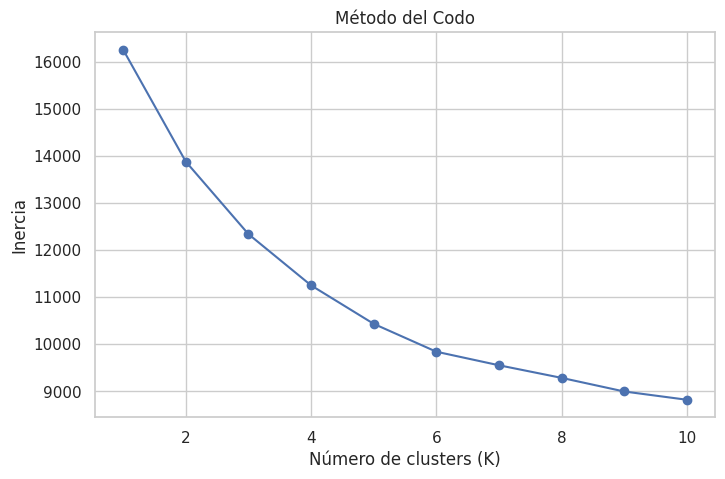

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

variables = ['Age', 'Gender', 'Race', 'State', 'Armed/Unarmed', 'Fleeing/Not fleeing']
df_cluster = df_limpio_2013[variables].copy()

numerical_features = ['Age']
categorical_features = ['Gender', 'Race', 'State', 'Armed/Unarmed', 'Fleeing/Not fleeing']

preprocesador = ColumnTransformer([
    ('num', MinMaxScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

X = preprocesador.fit_transform(df_cluster)

# Calcular inercia para varios valores de K
inercia = []
K_range = range(1, 11)

for k in K_range:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X)
    inercia.append(modelo.inertia_)

# Graficar método del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inercia, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Filtrar las variables necesarias
variables = ['Age', 'Gender', 'Race', 'State', 'Armed/Unarmed', 'Fleeing/Not fleeing']
# Usar df_limpio_2013 que ya tiene los NaNs eliminados
df_cluster = df_limpio_2013[variables].copy()

# Preprocesamiento: escalar numéricos y codificar categóricas
preprocesador = ColumnTransformer([
    ('num', MinMaxScaler(), ['Age']),
    ('cat', OneHotEncoder(drop='first'), ['Gender', 'Race', 'State', 'Armed/Unarmed', 'Fleeing/Not fleeing'])
])

# Transformar los datos
X = preprocesador.fit_transform(df_cluster)

# Aplicar KMeans con K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10) # Added n_init explicitly
kmeans.fit(X)
df_cluster['Cluster'] = kmeans.labels_

# Analizar los resultados
print("Cantidad de registros por cluster:")
print(df_cluster['Cluster'].value_counts())



Cantidad de registros por cluster:
Cluster
3    2987
0    2417
1    1146
4     910
2     823
Name: count, dtype: int64


In [ ]:
df_cluster['Cluster'] = kmeans.labels_


/tmp/ipython-input-2137190121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df_cluster, palette='Set2')


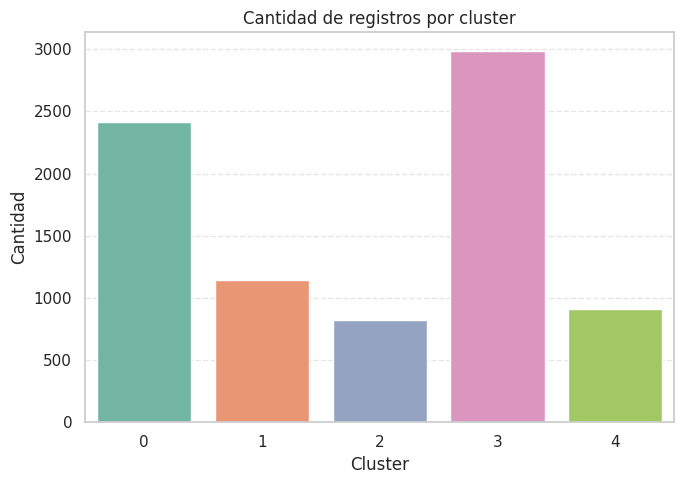

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.countplot(x='Cluster', data=df_cluster, palette='Set2')
plt.title('Cantidad de registros por cluster')
plt.xlabel('Cluster')
plt.ylabel('Cantidad')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
#Edad promedio por cluster
print(df_cluster.groupby('Cluster')['Age'].mean().round(1))


Cluster
0    38.5
1    31.1
2    34.6
3    41.7
4    35.0
Name: Age, dtype: float64


In [ ]:

df_cluster_filtered_gender = df_cluster[df_cluster['Gender'] != 'Transgender'].copy()


print("Distribución de género por cluster (excluyendo Transgender por ser NA):")
print(df_cluster_filtered_gender.groupby('Cluster')['Gender'].value_counts(normalize=True).unstack().round(2))

Distribución de género por cluster (excluyendo Transgender por ser NA):
Gender   Female  Male
Cluster              
0          0.03  0.97
1          0.02  0.98
2          0.04  0.96
3          0.05  0.95
4          0.03  0.97


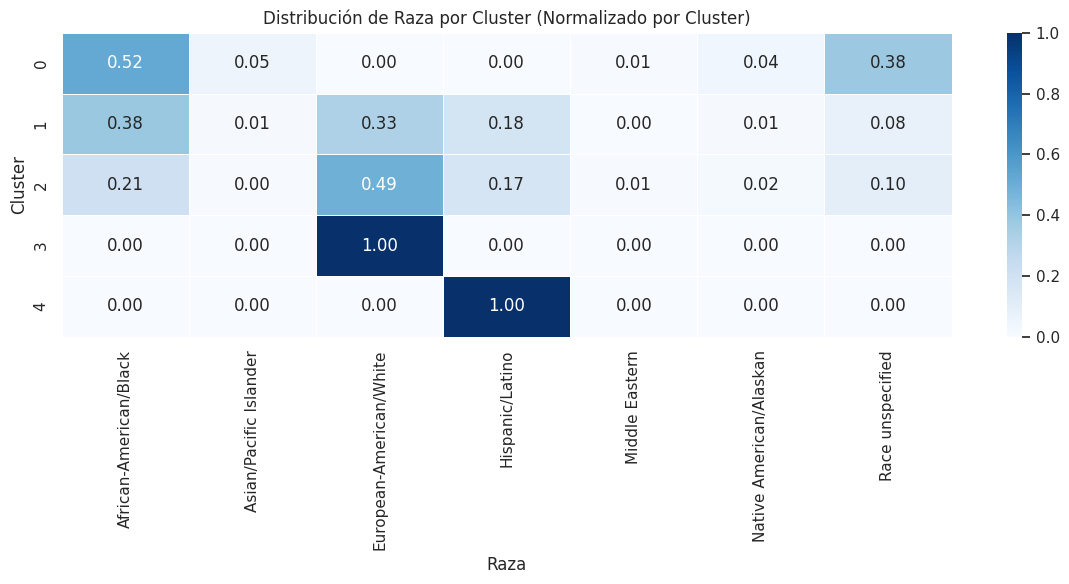

In [ ]:
# Tabla cruzada normalizada por cluster
tabla = pd.crosstab(df_cluster['Cluster'], df_cluster['Race'], normalize='index')

plt.figure(figsize=(12, 6)) # Ajustar el tamaño para mejor visualización si hay muchas razas
sns.heatmap(tabla, annot=True, cmap='Blues', fmt='.2f', linewidths=.5) # Añadir linewidths para separar celdas
plt.title('Distribución de Raza por Cluster (Normalizado por Cluster)')
plt.ylabel('Cluster')
plt.xlabel('Raza')
plt.tight_layout()
plt.show()

In [ ]:
# Estado con más casos en cada cluster
estado_mas_comun = df_cluster.groupby('Cluster')['State'].agg(lambda x: x.value_counts().idxmax())
print(estado_mas_comun)

Cluster
0    CA
1    CA
2    CA
3    CA
4    CA
Name: State, dtype: object


In [ ]:
#Armado o desarmado por cluster
armado = df_cluster.groupby('Cluster')['Armed/Unarmed'].agg(lambda x: x.value_counts().idxmax())
print(armado)

Cluster
0    Armed
1    Armed
2    Armed
3    Armed
4    Armed
Name: Armed/Unarmed, dtype: object


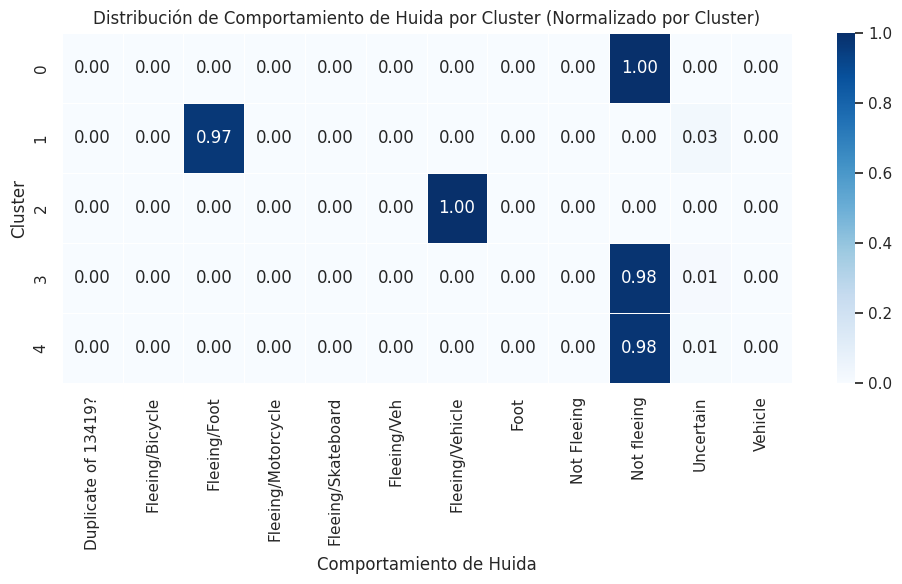

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegúrate de que df_cluster contiene los datos que quieres visualizar,
# incluyendo la columna 'Cluster' y la columna 'Fleeing/Not fleeing'.

# Calcular la tabla cruzada normalizada por clúster
# Rellenar NaN con 0 para que el heatmap se vea mejor si hay categorías que no aparecen en algunos clusters
tabla_fleeing = pd.crosstab(df_cluster['Cluster'], df_cluster['Fleeing/Not fleeing'], normalize='index').fillna(0)

plt.figure(figsize=(10, 6)) # Ajusta el tamaño según la cantidad de columnas resultantes
sns.heatmap(tabla_fleeing, annot=True, cmap='Blues', fmt='.2f', linewidths=.5)
plt.title('Distribución de Comportamiento de Huida por Cluster (Normalizado por Cluster)')
plt.ylabel('Cluster')
plt.xlabel('Comportamiento de Huida')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1825468984.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')


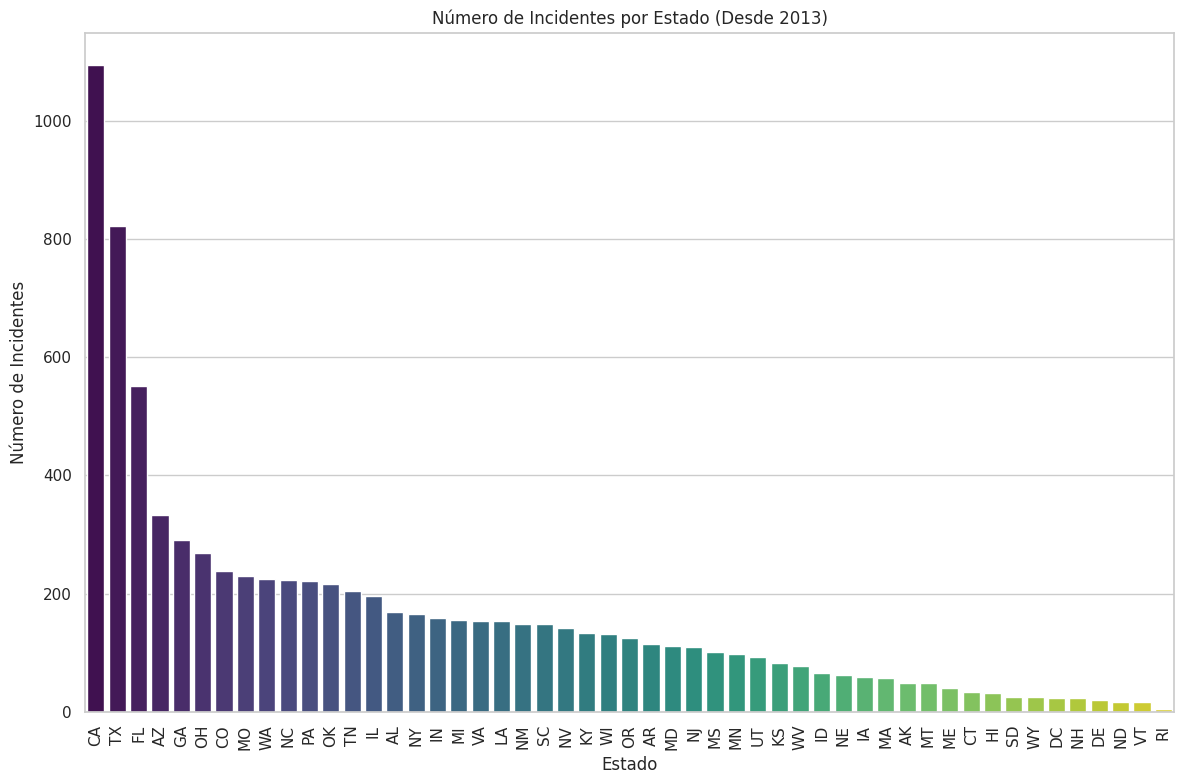

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

state_counts = df_limpio_2013['State'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')
plt.title('Número de Incidentes por Estado (Desde 2013)')
plt.xlabel('Estado')
plt.ylabel('Número de Incidentes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Limpiar las columnas 'Latitude' y 'Longitude': eliminar comas y convertir a numérico
# Convertir a string para aplicar str.replace
df_limpio_2013['Latitude'] = df_limpio_2013['Latitude'].astype(str).str.replace(',', '.', regex=False)
df_limpio_2013['Longitude'] = df_limpio_2013['Longitude'].astype(str).str.replace(',', '.', regex=False)

# Convertir a numérico, los errores se convertirán a NaN
df_limpio_2013['Latitude'] = pd.to_numeric(df_limpio_2013['Latitude'], errors='coerce')
df_limpio_2013['Longitude'] = pd.to_numeric(df_limpio_2013['Longitude'], errors='coerce')

# Eliminar filas donde 'Latitude' o 'Longitude' sean NaN después de la conversión
df_limpio_2013.dropna(subset=['Latitude', 'Longitude'], inplace=True)

/tmp/ipython-input-3835957264.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio_2013['Latitude'] = df_limpio_2013['Latitude'].astype(str).str.replace(',', '.', regex=False)
/tmp/ipython-input-3835957264.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio_2013['Longitude'] = df_limpio_2013['Longitude'].astype(str).str.replace(',', '.', regex=False)
/tmp/ipython-input-3835957264.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

In [ ]:
import pandas as pd
import plotly.express as px


conteo_estados = df_limpio_2013['State'].value_counts().reset_index()
conteo_estados.columns = ['State', 'Cantidad']


fig = px.choropleth(
    conteo_estados,
    locations='State',
    locationmode='USA-states',
    color='Cantidad',
    scope='usa',
    color_continuous_scale='Reds',
    title='Cantidad de casos por estado'
)

fig.show()

##Análisis de sentimientos

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
try:
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except Exception as e:
    print(f"Error al descargar datos de NLTK: {e}")


In [ ]:
# Asegurar que la columna no tenga valores nulos y sea de tipo string
df_limpio_2013['Brief description'] = df_limpio_2013['Brief description'].fillna('').astype(str)

# Función para limpiar el texto
def clean_text(text):
    text = text.lower()  # Convertir a minúsculas
    text = re.sub(r'[^a-z\s]', '', text)  # Eliminar caracteres especiales y números
    text = re.sub(r'\s+', ' ', text).strip()  # Eliminar espacios extra
    words = text.split()
    stop_words = set(stopwords.words('english'))  # Palabras vacías en inglés
    words = [word for word in words if word not in stop_words]  # Eliminar stopwords
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]  # Lematización
    return ' '.join(words)

# Aplicar la limpieza
df_limpio_2013['cleaned_description'] = df_limpio_2013['Brief description'].apply(clean_text)


/tmp/ipython-input-1329893273.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-1329893273.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
import numpy as np
from textblob import TextBlob

# Análisis de sentimiento con PANAS-tDL

# Función para obtener la polaridad de sentimiento
def analizar_sentimiento(texto):
    blob = TextBlob(texto)
    return blob.sentiment.polarity

# Aplicar análisis de sentimiento
df_limpio_2013['sentiment_polarity'] = df_limpio_2013['cleaned_description'].apply(analizar_sentimiento)

# Definimos las categorías PANAS-tDL y sus valores asociados
cols = ["Amenaza", "Pesimismo", "Inestabilidad", "Escepticismo", "Indiferente", "Neutral",
        "Favorable", "Optimismo", "Convicción", "Consolidado", "Confianza"]

pol = np.array([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

# Función para asignar categoría PANAS-tDL según la polaridad
def obtener_categoria_panas(polaridad):
    idx = (np.abs(pol - polaridad)).argmin()  # índice del valor más cercano
    return cols[idx]

# Aplicar clasificación PANAS-tDL
df_limpio_2013['PANAS_tDL'] = df_limpio_2013['sentiment_polarity'].apply(obtener_categoria_panas)

# Mostrar las primeras filas del resultado
df_limpio_2013[['cleaned_description', 'sentiment_polarity', 'PANAS_tDL']].head()



/tmp/ipython-input-1892672432.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-1892672432.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,cleaned_description,sentiment_polarity,PANAS_tDL
15243,omaha police department responded domestic dis...,-0.054545,Neutral
15244,deputy responded call shot fired andrew l clos...,0.200000,Favorable
15246,christopher two others car pueblo police offic...,-0.100000,Indiferente
15248,officer responded report chavez killed woman c...,-0.133333,Indiferente
15249,officer responded report gunshot apartment com...,-0.094805,Neutral


In [ ]:
print("Distribución de Sentimiento:")
conteo = df_limpio_2013['PANAS_tDL'].value_counts()
print(conteo)

# Mostrar primeras filas con las columnas nuevas
from IPython.display import display
display(df_limpio_2013[['Brief description', 'cleaned_description', 'sentiment_polarity', 'PANAS_tDL']].head())


Distribución de Sentimiento:
PANAS_tDL
Indiferente      4158
Neutral          3531
Favorable         324
Escepticismo      175
Optimismo          43
Inestabilidad      43
Pesimismo           4
Convicción          2
Consolidado         2
Amenaza             1
Name: count, dtype: int64


,Brief description,cleaned_description,sentiment_polarity,PANAS_tDL
15243,Omaha Police Department responded to a 911 dom...,omaha police department responded domestic dis...,-0.054545,Neutral
15244,Deputies responded to a 911 call of shots fire...,deputy responded call shot fired andrew l clos...,0.200000,Favorable
15246,Christopher was with two others in a car. Pueb...,christopher two others car pueblo police offic...,-0.100000,Indiferente
15248,An officer responded to a report by Chavez tha...,officer responded report chavez killed woman c...,-0.133333,Indiferente
15249,Officers responded to reports of gunshots at a...,officer responded report gunshot apartment com...,-0.094805,Neutral


In [ ]:
from collections import Counter
import re

def clean_text_for_count(text):
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = re.sub(r'[^a-záéíóúñü\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

top_n = 15
for categoria in df_limpio_2013['PANAS_tDL'].unique():
    textos = df_limpio_2013.loc[df_limpio_2013['PANAS_tDL'] == categoria, 'cleaned_description'].dropna().astype(str)
    todo = " ".join(textos)
    todo = clean_text_for_count(todo)
    counts = Counter(todo.split())
    most_common = counts.most_common(top_n)
    print(f"\nTop {top_n} palabras en categoría '{categoria}' (n={len(textos)} descripciones):")
    for w, c in most_common:
        print(f"  {w}: {c}")




Top 15 palabras en categoría 'Neutral' (n=3531 descripciones):
  officer: 4967
  police: 4491
  shot: 3390
  deputy: 1698
  killed: 1690
  man: 1600
  said: 1356
  gun: 1345
  home: 1105
  vehicle: 859
  fired: 817
  car: 787
  responded: 759
  allegedly: 750
  found: 700

Top 15 palabras en categoría 'Favorable' (n=324 descripciones):
  officer: 485
  police: 400
  shot: 298
  deputy: 160
  gun: 121
  man: 107
  killed: 97
  said: 94
  fired: 87
  vehicle: 84
  home: 83
  responded: 76
  knife: 68
  call: 66
  fire: 62

Top 15 palabras en categoría 'Indiferente' (n=4158 descripciones):
  police: 4926
  officer: 4879
  shot: 4614
  killed: 3748
  deputy: 1770
  man: 1713
  allegedly: 1537
  gun: 1347
  said: 1319
  home: 1141
  responded: 809
  fired: 760
  vehicle: 749
  knife: 723
  found: 696

Top 15 palabras en categoría 'Escepticismo' (n=175 descripciones):
  officer: 220
  police: 186
  shot: 158
  killed: 116
  deputy: 98
  man: 92
  said: 61
  vehicle: 56
  knife: 50
  gun: 42

In [ ]:
# Sentimiento de panas tdl predominante por cluster
df_limpio_2013 = df_limpio_2013.copy()
df_limpio_2013['Cluster'] = df_cluster['Cluster']
print("Sentimiento PANAS-tDL predominante por cluster:")
print(df_limpio_2013.groupby('Cluster')['PANAS_tDL'].agg(lambda x: x.value_counts().idxmax()))

Sentimiento PANAS-tDL predominante por cluster:
Cluster
0    Indiferente
1    Indiferente
2        Neutral
3    Indiferente
4    Indiferente
Name: PANAS_tDL, dtype: object


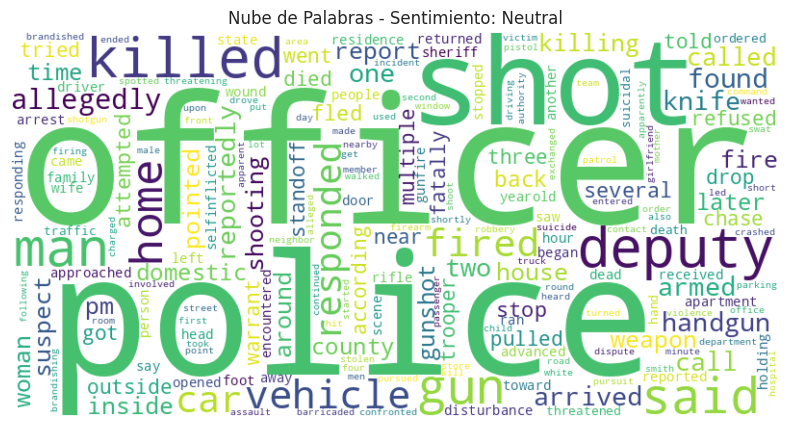

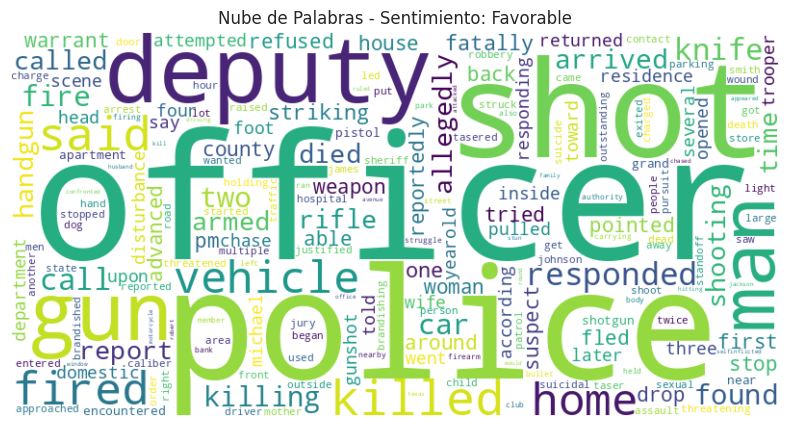

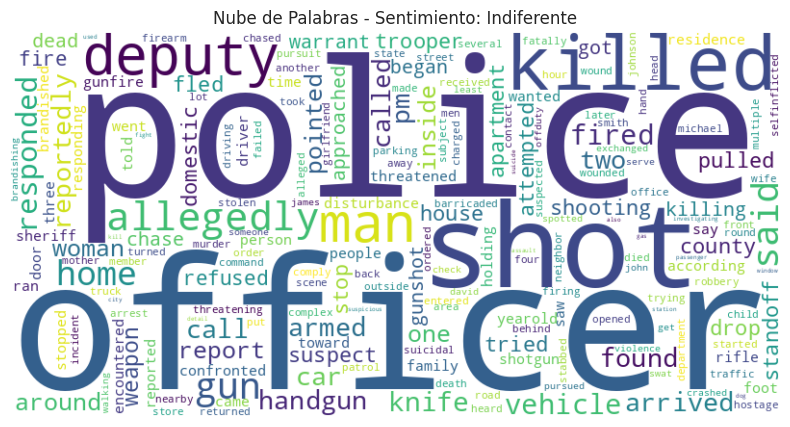

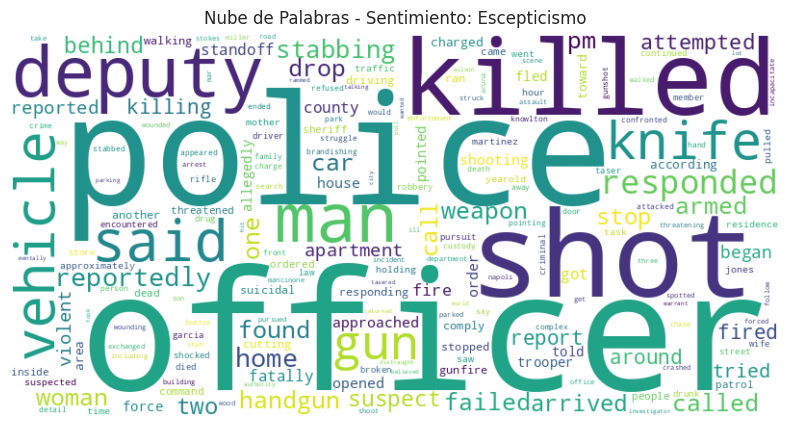

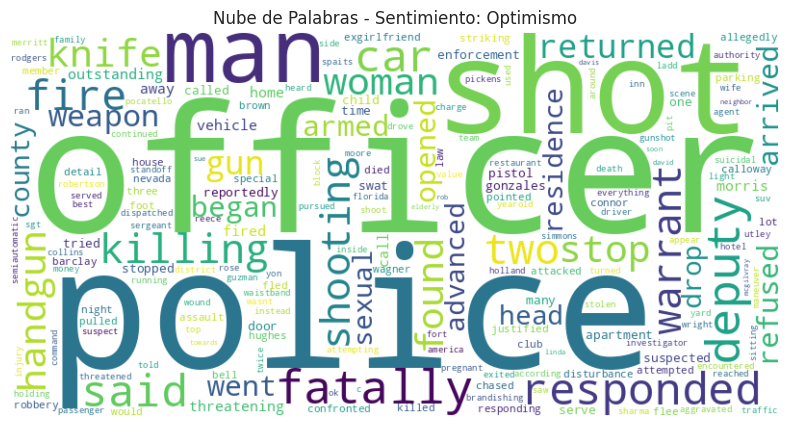

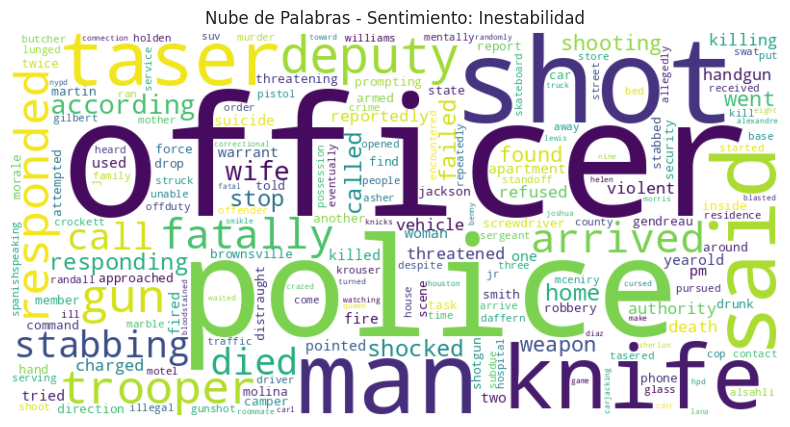

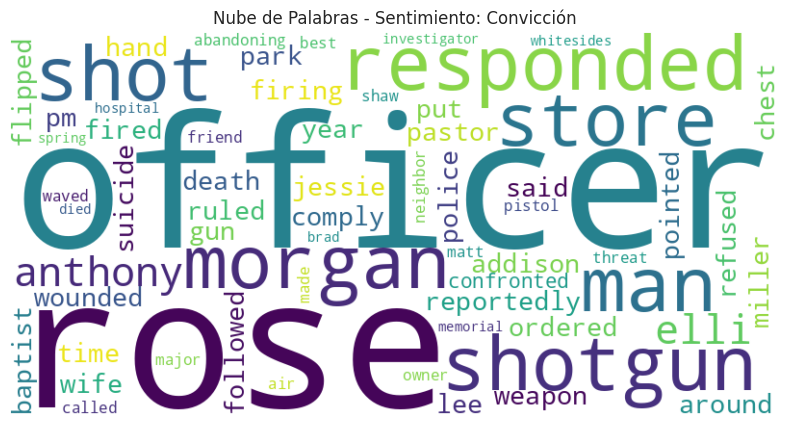

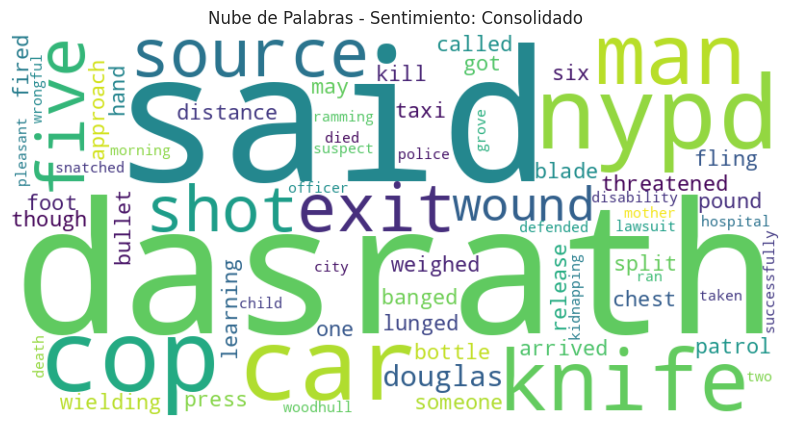

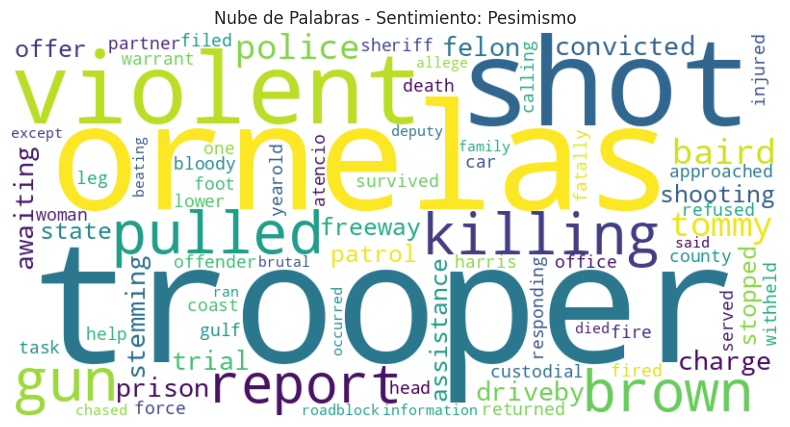

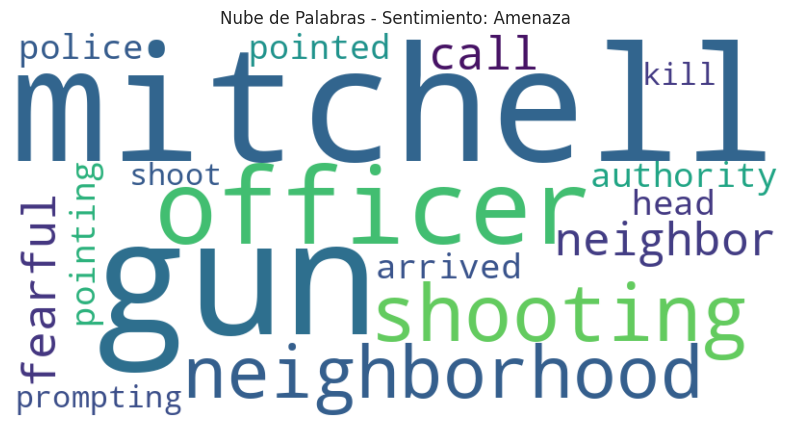

In [ ]:

# Generar nubes de palabras para todas las categorías de sentimiento
for sentiment_category in df_limpio_2013['PANAS_tDL'].dropna().unique():
    # Filtrar descripciones para la categoría de sentimiento actual
    textos = df_limpio_2013[df_limpio_2013['PANAS_tDL'] == sentiment_category]['cleaned_description'].dropna()

    # Unir todas las descripciones en una sola cadena
    all_words = ' '.join(textos).split()

    # Contar la frecuencia de las palabras
    word_counts = Counter(all_words)

    # Verificar si hay palabras para generar una nube de palabras
    if word_counts:
        # Generar la nube de palabras
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

        # Graficar la nube de palabras
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Nube de Palabras - Sentimiento: {sentiment_category}')
        plt.show()


/tmp/ipython-input-2060632340.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




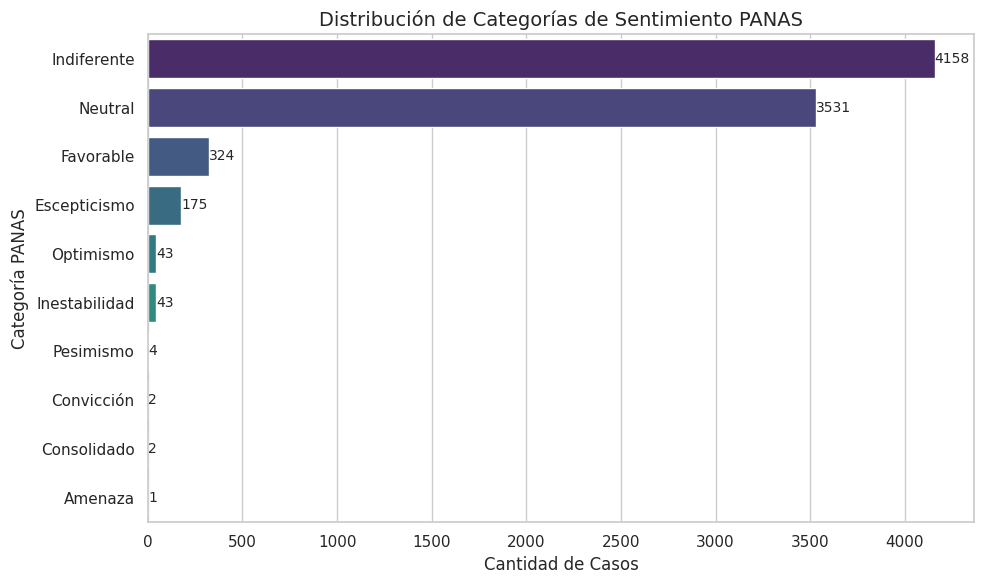

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Verificar existencia y datos de la columna
if 'PANAS_tDL' not in df_limpio_2013.columns:
    raise KeyError("La columna 'PANAS_tDL' no existe en el DataFrame.")
else:
    # Obtener las categorías únicas (ordenadas por frecuencia)
    categorias = df_limpio_2013['PANAS_tDL'].value_counts().index.tolist()

    # Estilo visual
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Gráfico de barras
    ax = sns.countplot(
        y='PANAS_tDL',  # gráfico horizontal para mejor lectura si hay muchas categorías
        data=df_limpio_2013,
        order=categorias,
        palette='viridis'
    )

    # Títulos y etiquetas
    plt.title('Distribución de Categorías de Sentimiento PANAS', fontsize=14)
    plt.xlabel('Cantidad de Casos')
    plt.ylabel('Categoría PANAS')

    # Mostrar valores encima de las barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

    plt.tight_layout()
    plt.show()



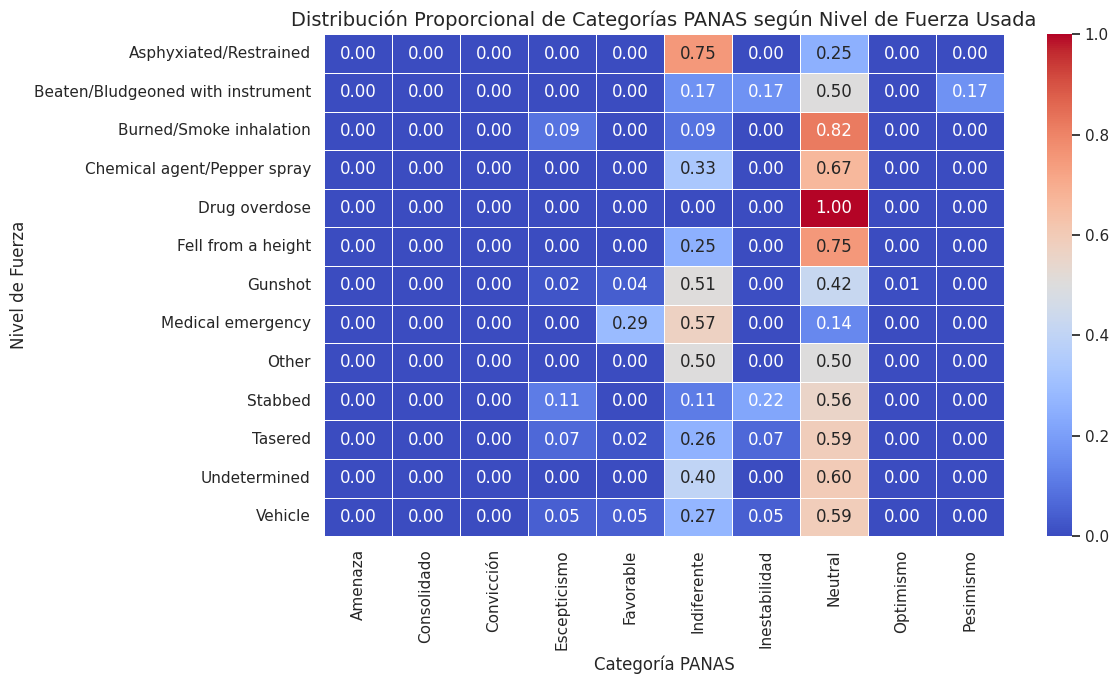

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Verificar columnas
if 'Highest level of force' not in df_limpio_2013.columns or 'PANAS_tDL' not in df_limpio_2013.columns:
    raise KeyError("Faltan las columnas 'Highest level of force' o 'PANAS_tDL' en el DataFrame.")

# Calcular proporciones de categorías PANAS por nivel de fuerza
tabla_panas_fuerza = pd.crosstab(
    df_limpio_2013['Highest level of force'],
    df_limpio_2013['PANAS_tDL'],
    normalize='index'
)

# Graficar heatmap de proporciones
plt.figure(figsize=(12, 7))
sns.heatmap(tabla_panas_fuerza, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

plt.title('Distribución Proporcional de Categorías PANAS según Nivel de Fuerza Usada', fontsize=14)
plt.xlabel('Categoría PANAS', fontsize=12)
plt.ylabel('Nivel de Fuerza', fontsize=12)
plt.tight_layout()
plt.show()


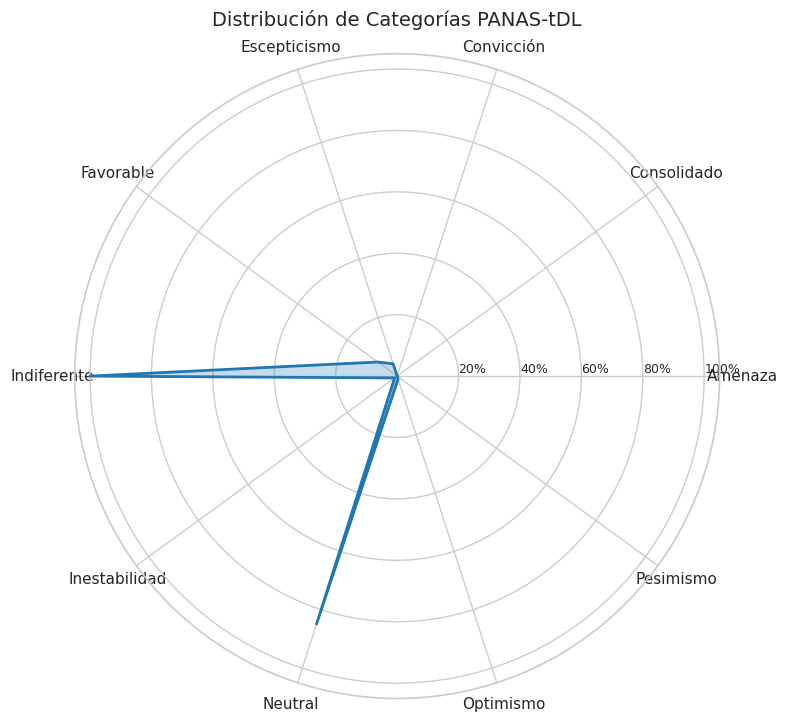

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Asegurarse de que la columna existe
if 'PANAS_tDL' not in df_limpio_2013.columns:
    raise KeyError("La columna 'PANAS_tDL' no existe en el DataFrame.")

# Contar frecuencia de cada categoría PANAS
conteo_panas = df_limpio_2013['PANAS_tDL'].value_counts().sort_index()

# Extraer categorías y valores
categorias = conteo_panas.index.tolist()
valores = conteo_panas.values

# Normalizar los valores si se desea mostrar proporciones (opcional)
valores_norm = valores / valores.max()

# Crear el ángulo para cada eje del radar
N = len(categorias)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
valores_norm = np.concatenate((valores_norm, [valores_norm[0]]))  # cerrar el círculo
angulos += [angulos[0]]

# Crear gráfico
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Dibujar el radar
ax.plot(angulos, valores_norm, color='tab:blue', linewidth=2)
ax.fill(angulos, valores_norm, color='tab:blue', alpha=0.25)

# Ajustar etiquetas de los ejes
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11)

# Títulos y detalles
ax.set_title('Distribución de Categorías PANAS-tDL', fontsize=14, pad=20)
ax.set_rlabel_position(0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
#conteo de palabras mas frecuentes por Cluster
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def clean_text_for_count(text):
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = re.sub(r'[^a-záéíóúñü\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    words = t.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

top_n = 15
for cluster_id in df_cluster['Cluster'].unique():
    textos = df_limpio_2013.loc[df_cluster['Cluster'] == cluster_id, 'Brief description'].dropna().astype(str)
    todo = " ".join([clean_text_for_count(text) for text in textos])
    counts = Counter(todo.split())
    most_common = counts.most_common(top_n)

    print(f"\nTop {top_n} palabras en Cluster '{cluster_id}' (n={len(textos)} descripciones):")
    for w, c in most_common:
        print(f"  {w}: {c}")


Top 15 palabras en Cluster '0' (n=2417 descripciones):
  police: 2923
  shot: 2356
  officers: 1997
  killed: 1702
  man: 1189
  officer: 1149
  said: 848
  gun: 795
  home: 766
  allegedly: 700
  deputies: 554
  responded: 552
  fired: 496
  found: 478
  knife: 467

Top 15 palabras en Cluster '3' (n=2987 descripciones):
  police: 3443
  shot: 2763
  officers: 2299
  killed: 1985
  officer: 1250
  man: 1186
  home: 1103
  deputies: 1079
  gun: 1044
  said: 1001
  allegedly: 778
  responded: 683
  deputy: 641
  fired: 605
  arrived: 596

Top 15 palabras en Cluster '1' (n=1146 descripciones):
  police: 1506
  shot: 1103
  officers: 1055
  killed: 761
  officer: 716
  man: 489
  gun: 449
  said: 424
  fled: 379
  foot: 336
  allegedly: 331
  car: 324
  vehicle: 319
  fired: 297
  handgun: 266

Top 15 palabras en Cluster '4' (n=910 descripciones):
  police: 1082
  shot: 906
  officers: 855
  killed: 639
  officer: 519
  man: 496
  said: 330
  gun: 317
  allegedly: 284
  knife: 259
  home:

Este conteo de palabras nos indica cuáles son las palabras más frecuentes por cada cluster

#Informe Final
###Introducción

Este estudio tuvo como objetivo analizar los patrones de uso de la fuerza letal por parte de cuerpos policiales en Estados Unidos, basándose en registros de muertes ocurridas entre el 2013 y años posteriores. Se utilizó una base de datos detallada con información sobre las víctimas, incluyendo edad, raza, género, estado, nivel de fuerza utilizada, estado de huida, si portaban armas, y descripciones breves del suceso.

A partir de un riguroso proceso de limpieza y transformación de los datos, se aplicaron técnicas de agrupamiento (clustering) y análisis de sentimientos para descubrir patrones ocultos que puedan sugerir sesgos raciales, geográficos o de comportamiento en el uso de la fuerza policial.


###Metodología

El enfoque general del trabajo se dividió en las siguientes etapas:

- Filtrado y limpieza de datos: Se depuró la base original eliminando valores nulos o inconsistentes, especialmente en variables clave como la edad, el estado o el tipo de arma utilizada.
- Transformación de variables: Se creó una columna para sentimientos a partir de descripciones breves del evento, y se estandarizaron variables como género, raza, y tipo de fuerza.
- Clusterización (K-Means): Se agruparon los datos en 5 clústeres utilizando características como edad, raza, género, y nivel de fuerza. Se empleó el método del codo para determinar el número óptimo de clústeres.
- Análisis de sentimiento y lenguaje: Se analizaron los textos descriptivos con  Panas- tdl segun polaridad para entender el tono emocional y extraer palabras más frecuentes por clúster.



###Resultados y Hallazgos Principales

- El análisis se enfocó principalmente en el estado de California (CA), donde se ubicaban casi todos los registros post-filtrado.
- Casi la totalidad de los casos eran hombres y la fuerza letal mas utilizada de los casos fue “Gunshot” (arma de fuego).
- Las edades de las víctimas oscilaban principalmente entre 20 y 60 años.

- Clúster 1:
También compuesto principalmente por personas afroamericanas, este grupo presenta una edad promedio de 31.1 años y un sentimiento promedio negativo (-0.0818), aunque ligeramente menos que el clúster anterior.
Las palabras clave más recurrentes —fled, foot, vehicle, allegedly, officer— indican que muchos de los casos ocurrieron durante intentos de huida, ya fuera a pie o en vehículos, y que existían sospechas o acusaciones previas hacia las víctimas.
El tono emocional general es indiferente, de acuerdo con la clasificación PANAS-tDL, reflejando una descripción objetiva del hecho más que una carga emocional explícita.
- Clúster 2:
Integrado mayoritariamente por personas blancas o euroamericanas, este grupo presenta una edad promedio de 34.6 años. Su sentimiento promedio (-0.0784) es el menos negativo de todos los clústeres.
Las palabras más comunes —vehicle, chase, stop, police, shot— sugieren que los eventos están asociados principalmente con persecuciones vehiculares o intervenciones de tránsito.
El sentimiento PANAS-tDL predominante es “Neutral”, lo que coincide con el tono más moderado de los relatos y con un tipo de interacción más impersonal o procedural.
- Clúster 3:
Este clúster también está conformado mayoritariamente por personas blancas o euroamericanas, con una edad promedio de 41.7 años y un sentimiento promedio de -0.0845.
En las descripciones predominan las palabras home, knife, responded, allegedly, killed, lo que apunta a situaciones domésticas o de respuesta policial ante individuos armados con objetos cortopunzantes.
El sentimiento PANAS-tDL predominante es “Indiferente”, evidenciando nuevamente un estilo narrativo más descriptivo que emocional, pese a la gravedad de los hechos.
- Clúster 4:
Finalmente, este grupo está compuesto principalmente por personas hispanas o latinas, con una edad promedio cercana a los 35 años. Todos los casos registrados involucran muertes por arma de fuego, y las víctimas son en su totalidad hombres.
El sentimiento promedio es negativo (-0.0942), el más bajo entre los clústeres. Las palabras más frecuentes —knife, home, responded, officer, killed— reflejan un patrón similar al del clúster 3, con incidentes ocurridos en domicilios y enfrentamientos con armas blancas.
El sentimiento PANAS-tDL predominante también es “Indiferente”, destacando una narrativa centrada en la descripción del evento más que en la emoción asociada.





###Análisis Crítico

Los resultados muestran patrones preocupantes en la forma como la policía ejerce la fuerza letal:

- La raza de la víctima es una variable claramente diferenciadora en la configuración de clústeres, lo cual indica una posible discriminación sistemática en el uso de la fuerza, especialmente contra personas afroamericanas y latinas.
- La edad parece tener un papel menos determinante, aunque la mayoría de los casos se concentran en adultos jóvenes.
- El lenguaje utilizado en los informes confirma la alta frecuencia de muertes en contextos de persecuciones, respuestas en hogares, y situaciones con armas blancas.


###Conclusiones

Este estudio confirma patrones preocupantes en el uso de la fuerza letal por parte de la policía, particularmente en el estado de California. A través del análisis de datos, se identificaron grupos poblacionales desproporcionadamente afectados, donde la raza emerge como un factor de riesgo importante.

El análisis de sentimientos y la clusterización permitieron identificar sesgos y tendencias estructurales que reflejan posibles desigualdades en las acciones policiales, resaltando la necesidad de mayor transparencia y control institucional.


###Recomendaciones

- Transparencia institucional: Las fuerzas policiales deben publicar informes detallados que incluyan descripciones completas y verificables de cada incidente.
- Capacitación en derechos humanos: Mayor formación en manejo de conflictos y no discriminación para los oficiales.
- Estudios continuos: Repetir este tipo de análisis de forma anual para monitorear avances o retrocesos.
- Auditorías externas: Permitir que entidades independientes analicen y supervisen el uso de la fuerza en situaciones policiales.
